# Energy Balance Model 

## Heat Equation In Spherical Coordinate 

We can discretize the earth to bands at different latitude. 

interactive(children=(IntSlider(value=5, description='N', max=30, min=5), Output()), _dom_classes=('widget-int…

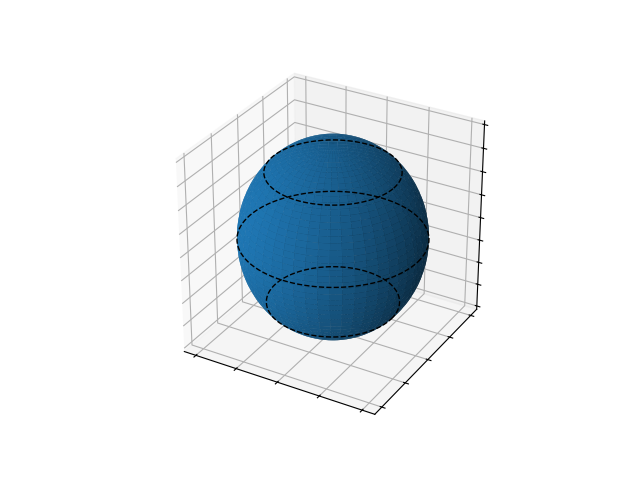

In [4]:
%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as wdgt
import numpy as np

fig = plt.figure()
global ax
ax = fig.add_subplot(projection='3d')
# Set an equal aspect ratio
ax.set_aspect('equal')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

theta = np.linspace(0, 2 * np.pi, 100)  #longitude 
phi = np.linspace(0, np.pi, 100) #latitude

x = np.outer(np.cos(theta), np.sin(phi)) #x at (theta,phi) is given by sin(phi)cos(theta)
y = np.outer(np.sin(theta), np.sin(phi)) #y at (theta, phi) is given by sin(phi)sin(theta)
z = np.outer(np.ones(np.size(theta)), 296*np.cos(phi)/297) #z at (theta, phi) is given by cos(phi) with a flattening 

# Plot the surface
ax.plot_surface(x, y, z, zorder=1)

#the resolution of the discretization
N = wdgt.IntSlider(value=5, min=5, max=30, step=1)

lines = []

def plot_discretization(N):
    global lines
    if len(lines) > 0:
        for line in lines:
            line.remove()
    lines = []
    for phi_ in np.linspace(0, np.pi, N):
        x = np.cos(theta) * np.sin(phi_) 
        y = np.sin(theta) * np.sin(phi_)
        z = 296*np.cos(phi_)/297
        new_line = (ax.plot(x, y, z, color='black', linewidth=1, linestyle='--', zorder=3))[0] #plot returns a list
        lines.append(new_line)
    plt.draw()

wdgt.interact(plot_discretization, N=N)
plt.show()